# BIDS EEG Data Reader

This notebook demonstrates how to load, inspect, and visualize EEG data from a BIDS (Brain Imaging Data Structure) formatted dataset using MNE-Python and MNE-BIDS libraries.

## 1. Import Required Libraries

Import necessary libraries for reading and visualizing BIDS EEG data.

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MNE and BIDS libraries
import mne
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Set BIDS Dataset Path

Define the path to your BIDS dataset directory. This should be the root directory containing the BIDS structure with subdirectories like `sub-*/ses-*/eeg/`.

In [2]:
# Set the path to your BIDS dataset
# Update this path to point to your BIDS dataset root directory
bids_root = r"d:\Hackathons\EPFL_Life_Sciences_2026\meditation-eeg\ds003969"

# Verify that the directory exists
if os.path.isdir(bids_root):
    print(f"BIDS root directory found: {bids_root}")
    print(f"Contents: {os.listdir(bids_root)}")
else:
    print(f"ERROR: BIDS root directory not found at {bids_root}")

BIDS root directory found: d:\Hackathons\EPFL_Life_Sciences_2026\meditation-eeg\ds003969
Contents: ['CHANGES', 'code', 'dataset_description.json', 'participants.json', 'participants.tsv', 'README', 'sourcedata', 'sub-001']


## 3. Load BIDS Dataset Structure

Explore the BIDS dataset structure and list available subjects and sessions.

In [3]:
# Get list of subjects in the BIDS dataset
try:
    subjects = get_entity_vals(bids_root, entity_key='subject')
    print(f"Available subjects: {subjects}")
    print(f"Number of subjects: {len(subjects)}\n")
    
    # Get sessions if available
    sessions = get_entity_vals(bids_root, entity_key='session')
    if sessions:
        print(f"Available sessions: {sessions}")
        print(f"Number of sessions: {len(sessions)}\n")
    
    # Get tasks
    tasks = get_entity_vals(bids_root, entity_key='task')
    if tasks:
        print(f"Available tasks: {tasks}")
        print(f"Number of tasks: {len(tasks)}\n")
    
except Exception as e:
    print(f"Error exploring BIDS structure: {e}")

Available subjects: ['001']
Number of subjects: 1

Available tasks: ['med1breath', 'med2', 'think1', 'think2']
Number of tasks: 4



## 4. Read EEG Data Files

Load EEG data files using `read_raw_bids()` function. This example reads the first subject's EEG data.

In [4]:
# Read EEG data for the first subject
try:
    if subjects:
        # Create a BIDS path for the first subject
        subject = subjects[0]
        session = sessions[0] if sessions else None
        task = tasks[0] if tasks else None
        
        bids_path = BIDSPath(
            subject=subject,
            session=session,
            task=task,
            datatype='eeg',
            root=bids_root
        )
        
        print(f"Reading BIDS file: {bids_path}")
        
        # Read the raw EEG data
        raw = read_raw_bids(bids_path=bids_path, verbose=True)
        print(f"✓ Successfully loaded EEG data!")
        print(f"Data shape: {raw.get_data().shape}")
        
    else:
        print("No subjects found in the BIDS dataset!")
        raw = None
        
except Exception as e:
    print(f"Error reading EEG data: {e}")
    raw = None

Reading BIDS file: d:/Hackathons/EPFL_Life_Sciences_2026/meditation-eeg/ds003969/sub-001/eeg/sub-001_task-med1breath_eeg.bdf
Extracting BDF parameters from d:\Hackathons\EPFL_Life_Sciences_2026\meditation-eeg\ds003969\sub-001\eeg\sub-001_task-med1breath_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading channel info from d:\Hackathons\EPFL_Life_Sciences_2026\meditation-eeg\ds003969\sub-001\eeg\sub-001_task-med1breath_channels.tsv.


C:\Users\horvt\AppData\Local\Temp\ipykernel_4772\1882035225.py:20: RuntimeWarning: Did not find any events.tsv associated with sub-001_task-med1breath.

The search_str was "d:\Hackathons\EPFL_Life_Sciences_2026\meditation-eeg\ds003969\sub-001\**\eeg\sub-001*events.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=True)
C:\Users\horvt\AppData\Local\Temp\ipykernel_4772\1882035225.py:20: RuntimeWarning: The number of channels in the channels.tsv sidecar file (79) does not match the number of channels in the raw data file (80). Will not try to set channel names.
  raw = read_raw_bids(bids_path=bids_path, verbose=True)
C:\Users\horvt\AppData\Local\Temp\ipykernel_4772\1882035225.py:20: RuntimeWarning: Unable to map the following column(s) to to MNE:
gender: m
group: htr
ethnicity: indian
first_session: meditation
sleep: 6
education: 0
years_of_practice: 3
notes: n/a
  raw = read_raw_bids(bids_path=bids_path, verbose=True)


✓ Successfully loaded EEG data!
Data shape: (80, 620544)


## 5. Inspect EEG Data

Examine the EEG data properties including sampling rate, number of channels, duration, and channel information.

In [5]:
# Inspect the loaded data
if raw is not None:
    print("=" * 60)
    print("EEG DATA PROPERTIES")
    print("=" * 60)
    print(f"Sampling frequency: {raw.info['sfreq']} Hz")
    print(f"Number of channels: {len(raw.info['ch_names'])}")
    print(f"Channel names: {raw.info['ch_names']}")
    print(f"Data type: {raw.info['chs'][0]['kind']}")
    print(f"Recording duration: {raw.times[-1]:.2f} seconds ({raw.times[-1]/60:.2f} minutes)")
    print(f"Total number of samples: {raw.get_data().shape[1]}")
    print(f"Data shape (channels × samples): {raw.get_data().shape}")
    
    # Print summary information
    print("\n" + "=" * 60)
    print("CHANNEL INFORMATION")
    print("=" * 60)
    ch_types_dict = {}
    for ch_type in raw.get_channel_types():
        if ch_type not in ch_types_dict:
            ch_types_dict[ch_type] = 0
        ch_types_dict[ch_type] += 1
    
    for ch_type, count in ch_types_dict.items():
        print(f"{ch_type.upper()}: {count} channel(s)")
else:
    print("No raw data loaded. Please check the BIDS path and dataset structure.")

EEG DATA PROPERTIES
Sampling frequency: 1024.0 Hz
Number of channels: 80
Channel names: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']
Data type: 2 (FIFFV_EEG_CH)
Recording duration: 606.00 seconds (10.10 minutes)
Total number of samples: 620544
Data shape (channels × samples): (80, 620544)

CHANNEL INFORMATION
EEG: 64 channel(s)
MISC: 11 channel(s)
GSR: 2 channel(s)
RESP: 1 channel(s)
TEMPERATURE: 1 channel(s)
STIM: 1 channel(s)


## 6. Visualize EEG Signals

Plot and visualize the EEG signals to inspect data quality and signal characteristics.

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']


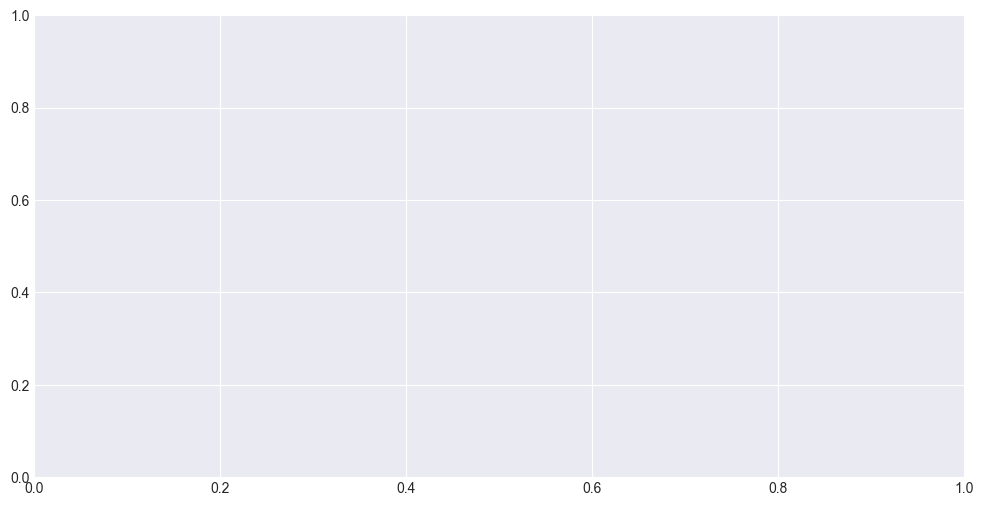

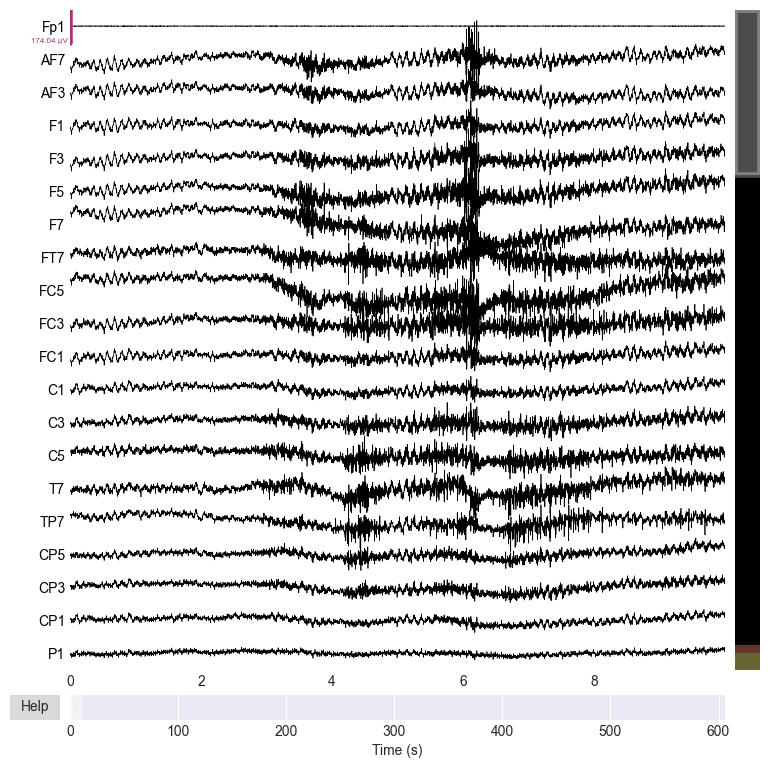

<Figure size 640x480 with 0 Axes>

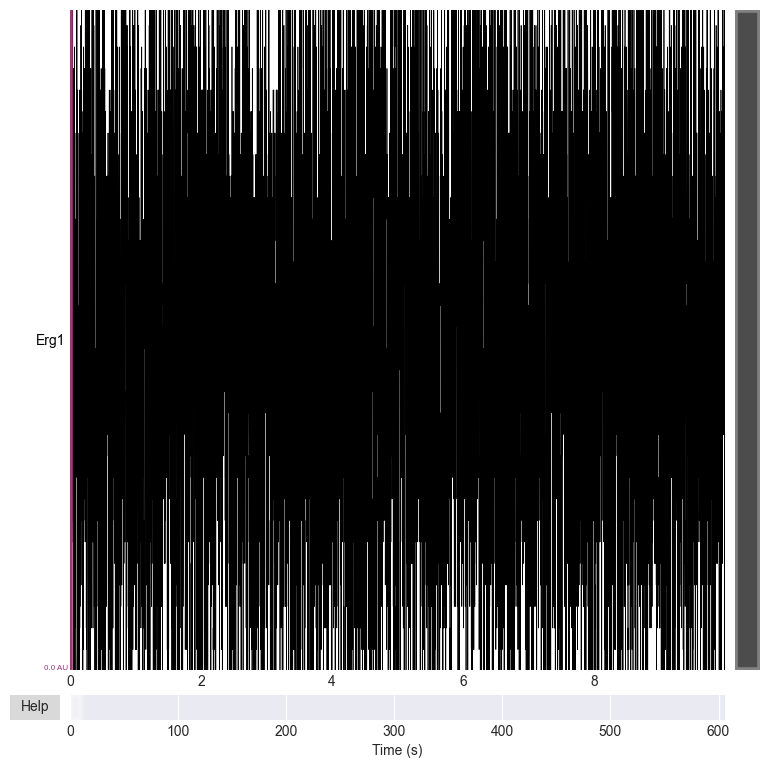

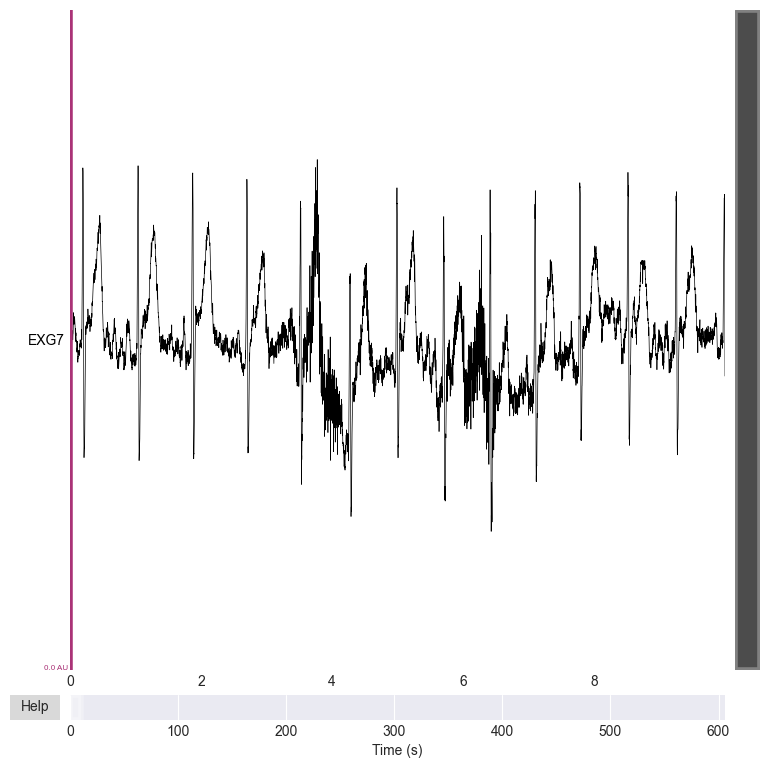

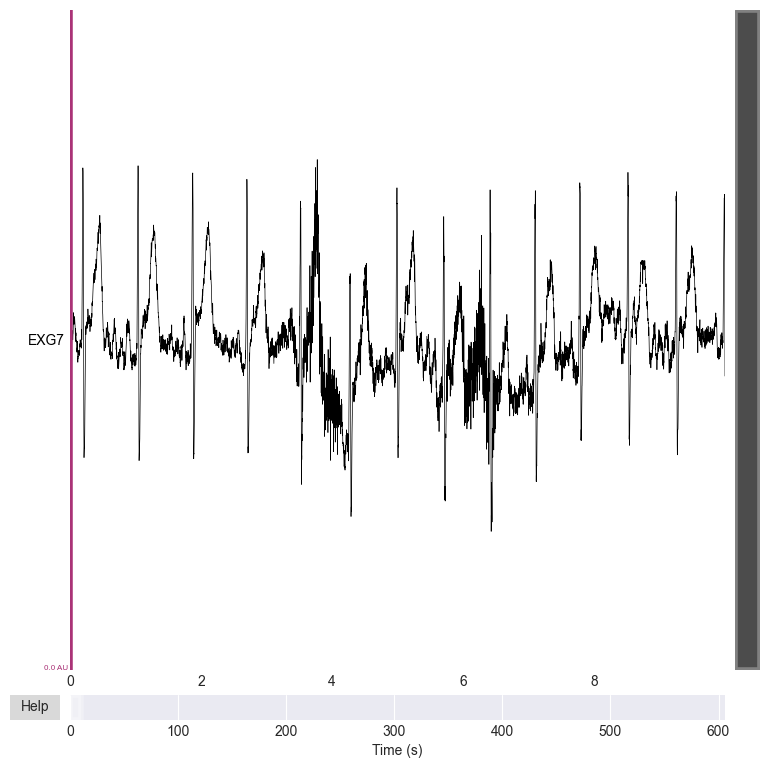

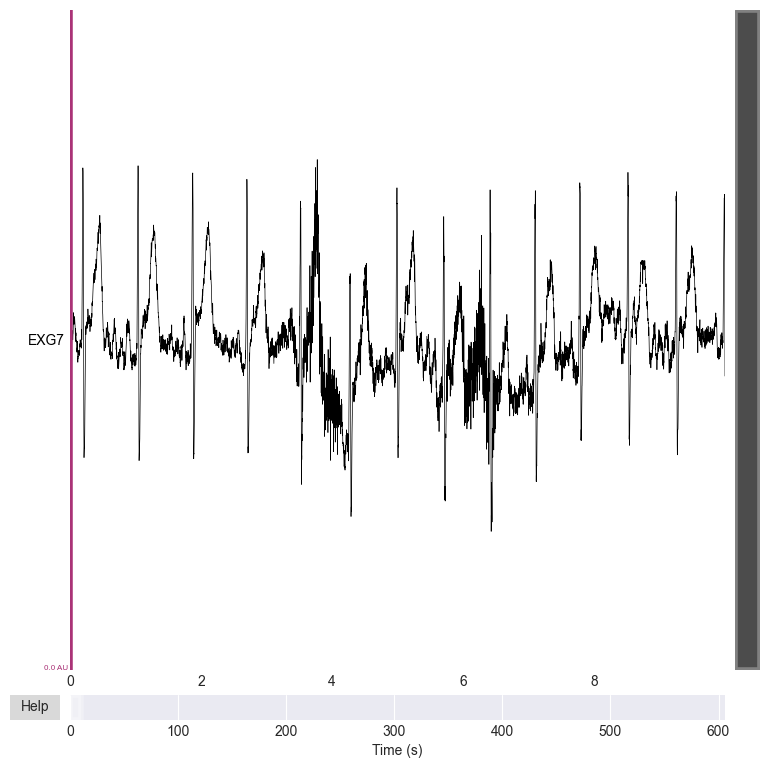

Effective window size : 2.000 (s)


TypeError: BaseSpectrum.plot() got an unexpected keyword argument 'ax'

In [12]:
# Visualize the first 10 seconds of EEG data
if raw is not None:
    print(raw.ch_names)

    # Plot a portion of the data
    fig = raw.plot(duration=10, n_channels=20, scalings='auto')
    plt.suptitle('EEG Signals - First 10 Seconds', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    raw.copy().pick(['EXG7']).plot()
    plt.show()

    # Create a power spectral density plot
    fig, ax = plt.subplots(figsize=(12, 6))
    raw.compute_psd(fmin=0.5, fmax=50, n_jobs=1).plot(ax=ax, show=False)
    ax.set_title('Power Spectral Density (PSD) - EEG Signals', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Plot channel locations (if montage is available)
    try:
        fig = raw.plot_sensors()
        plt.suptitle('EEG Channel Locations', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot channel locations: {e}")
else:
    print("No raw data to visualize. Please load data from a BIDS file first.")